[''] Not a value
Total number of entries =  100000


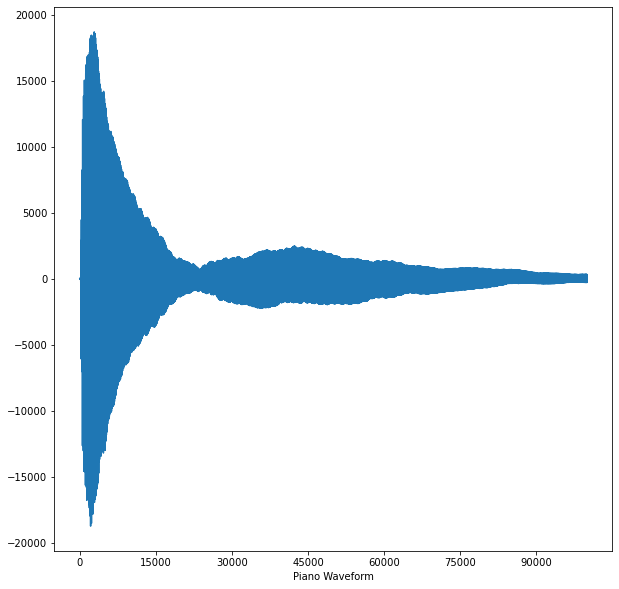

Waveform of  100000.0  has coefficient = 3032935.0
Waveform of  50000.0  has coefficient = 3480.6518112876715
Waveform of  33333.333333333336  has coefficient = 5061.772683710081
Waveform of  25000.0  has coefficient = 4512.042987173723
Waveform of  20000.0  has coefficient = 2956.70924281086
Waveform of  16666.666666666668  has coefficient = 5503.053066445988
Waveform of  14285.714285714286  has coefficient = 6504.225253425407
Waveform of  12500.0  has coefficient = 4713.151987893736
Waveform of  11111.111111111111  has coefficient = 2811.1666849456824
Waveform of  10000.0  has coefficient = 5583.302218451533
Waveform of  9090.90909090909  has coefficient = 1989.0494576903802
Waveform of  8333.333333333334  has coefficient = 7575.295145772576
Waveform of  7692.307692307692  has coefficient = 18091.096374219393
Waveform of  7142.857142857143  has coefficient = 16590.34717852065
Waveform of  6666.666666666667  has coefficient = 13436.680105227411
Waveform of  6250.0  has coefficient = 9

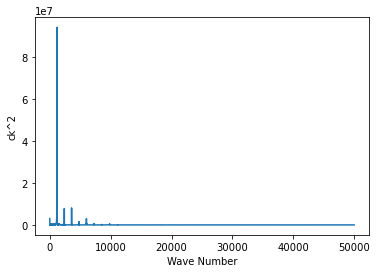

In [44]:
# Comp.Phys.HW5.Q1 : Exercise 7.3

from matplotlib.pylab import plot, show, xlim, ylim, xlabel, ylabel,hist
import numpy as np
from numpy.fft import rfft
import matplotlib.pyplot as plt
import urllib.request


url = 'http://www-personal.umich.edu/~mejn/cp/data/piano.txt'
with urllib.request.urlopen(url) as response:
    html = response.read()
    
data=html.decode().split("\n")
notes=[]
for entry in data:
    vals = entry.split(" ")
    if (len(vals) == 1):
        if vals[0] == '':
            print(vals, "Not a value")
        else:
#             print(vals)
            notes.append(float(vals[0]))
                 
print("Total number of entries = ", len(notes))

fig = plt.figure(figsize=(10,10))
axes = plt.axes()
axes.xaxis.set_major_locator(plt.MaxNLocator(10))
axes.yaxis.set_major_locator(plt.MaxNLocator(10))
plot(notes)
xlabel("Piano Waveform")
show()

#-------------------------------------------------
c = rfft(notes)
for k in range(10000):
    print("Waveform of ", 100000/(k+1), " has coefficient =", (abs(c[k])))
plot(abs(c))
xlabel("Wave Number")
ylabel("ck^2")

N = len(notes)
peak = np.argmax(c)
print("\n")
print("Where the plot peaks: ", peak)
freq = (peak * 44100) / N
print("\n")
print("With a frequency of: ",freq, "Hz -- this should be a Tenor C")

[''] Not a value
Total number of entries =  1024


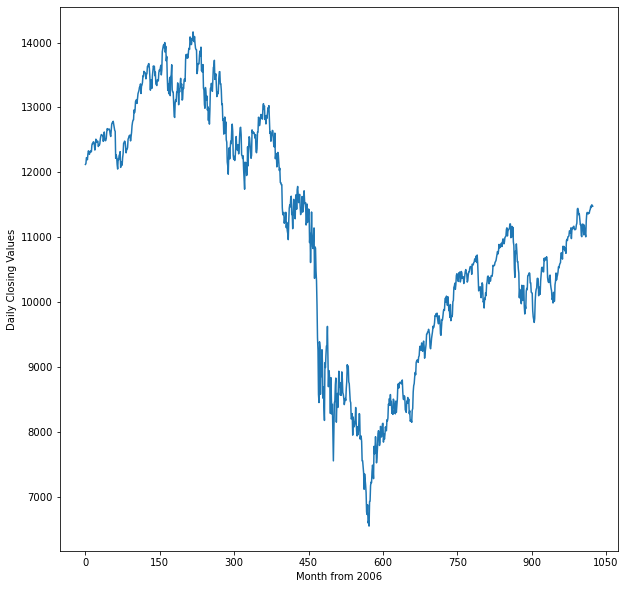

Discrete-Fourier
Value of  1024.0  has coefficient = 127326488127147.52
Value of  512.0  has coefficient = 1380222933583.1672
Value of  341.3333333333333  has coefficient = 184382685195.7702
Value of  256.0  has coefficient = 80477326603.77174
Value of  204.8  has coefficient = 6474850031.116139
Value of  170.66666666666666  has coefficient = 13419242912.577024
Value of  146.28571428571428  has coefficient = 1073756106.7202635
Value of  128.0  has coefficient = 738628207.212401
Value of  113.77777777777777  has coefficient = 1491959649.4376984
Value of  102.4  has coefficient = 1086450781.0794275
Value of  93.0909090909091  has coefficient = 12781357250.693031
Value of  85.33333333333333  has coefficient = 898919845.9659156
Value of  78.76923076923077  has coefficient = 8860362226.13134
Value of  73.14285714285714  has coefficient = 11716543002.399511
Value of  68.26666666666667  has coefficient = 662767053.675292
Value of  64.0  has coefficient = 1224135825.4118264
Value of  60.235294

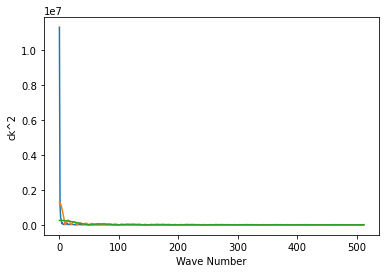

In [43]:
# Comp.Phys.HW5.Q1 : Exercise 7.4

from matplotlib.pylab import plot, show, xlim, ylim, xlabel, ylabel, hist
import numpy as np
from numpy.fft import rfft, irfft
import matplotlib.pyplot as plt
import urllib.request

# original data
url = 'http://www-personal.umich.edu/~mejn/cp/data/dow.txt'
with urllib.request.urlopen(url) as response:
    html = response.read()
    
data=html.decode().split("\n")
dc_val=[]
for entry in data:
    vals = entry.split(" ")
    if (len(vals) == 1):
        if vals[0] == '':
            print(vals, "Not a value")
        else:
#             print(vals)
            dc_val.append(float(vals[0]))
                 
                 
print("Total number of entries = ", len(dc_val))

fig = plt.figure(figsize=(10,10))
axes = plt.axes()
axes.xaxis.set_major_locator(plt.MaxNLocator(10))
axes.yaxis.set_major_locator(plt.MaxNLocator(10))
plot(dc_val)
xlabel("Month from 2006")
ylabel("Daily Closing Values")
show()

print("Discrete-Fourier")
# Discrete-Fourier 

N = 1024
c = rfft(dc_val)
for k in range(50):
    print("Value of ", 1024/(k+1), " has coefficient =", abs(c[k])**2)

print("\n")
plot(abs(c))
xlabel("Wave Number")
ylabel("ck^2")

# Inverse-Fourier -- all but first 10%  = 0
print("First Inverse-Fourier")

for i in range(N - 102):
    dc_val[-i] = 0
    
dc_val[0] = 12121.71
print("\n")
print(dc_val)
new_c1 = rfft(dc_val)
for k in range(50):
    print("Value of ", (1/N) * 1024/(k+1), " has coefficient =", abs(new_c1[k]))

plot(abs(new_c1))
# The plot of the Inverse-Fourier is more noticable that the Discrete-Fourier
# Inverse-Fourier starts a lot lower than Discrete-Fourier and seems to be most active
# around the area in which the Discrete-Fourier peaks

print("\n")

# Inverse-Fourier -- all but first 2%  = 0
print("Second Inverse-Fourier")
for i in range(N - 20):
    dc_val[-i] = 0
    
dc_val[0] = 12121.71
print(dc_val)

new_c2 = rfft(dc_val)
for k in range(50):
    print("Value of ", (1/N) * 1024/(k+1), " has coefficient =", abs(new_c2[k]))
    
plot(abs(new_c2))
# I feel like the 2nd Inverse_Fourier focues 
# even finer on the peak of the Discrete-Fourier plot
# which in turn we see the peaks of the first Inverse-Fourier under that of the 2nd



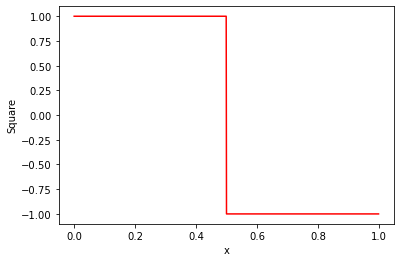

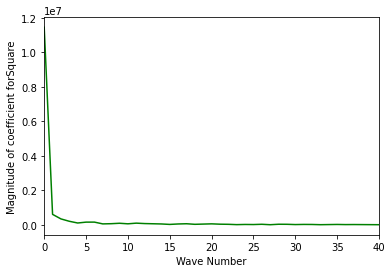

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0

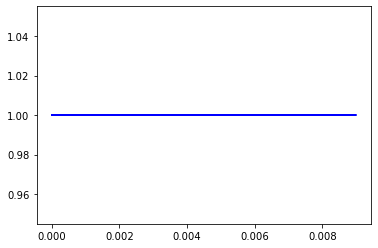

In [42]:
# Comp.Phys.HW5.Q1 : Exercise 7.5

from numpy import arange
from numpy.fft import rfft
from pylab import plot, show, xlim, xlabel, ylabel
from math import sin, pi

def f_square(x):
    if x < 0.5: return 1
    else: return -1
    
N = 1000

def discreteft(f, type):
    #discrete Fourier
    x = arange(0,1,1./N)
    y = [f(x) for x in x]
    c2 = rfft(y)
    plot(x,y, color="red")
    xlabel("x")
    ylabel(type)
    show()
    plot(abs(c), color="green")
    xlim(0,40)
    xlabel("Wave Number")
    ylabel("Magnitude of coefficient for" + type)
    show()
    
    #inverse Fourier
    for i in range(N - 9): # all but first ten values set = 0
        x[-i] = 0
    print(x) # just to make sure array is mainly filled with zeros
    y = [f(x) for x in x]
    c2 = (1/N) * rfft(y)
    plot(x,y, color="blue")
    show()
    
discreteft(f_square, "Square")

# something doesn't seem right regarding the inverse-Fourier
# I don't think it should be a straight line??

[''] Not a value
Total number of entries =  1024


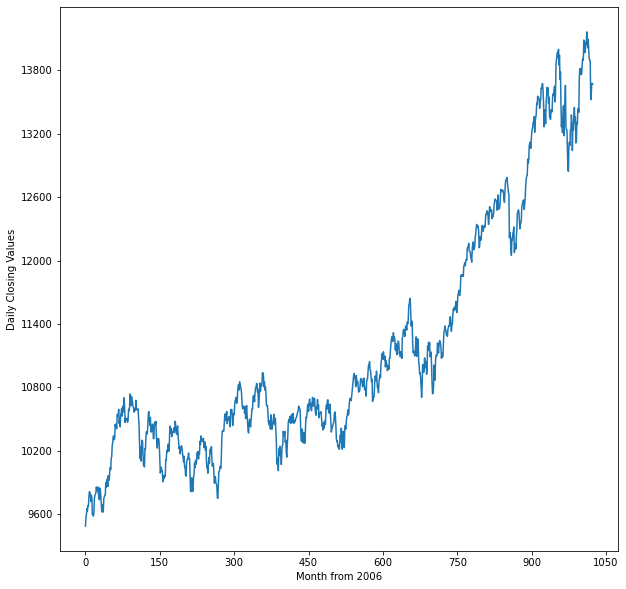

Discrete-Fourier
[9487.8, 9572.31, 9594.98, 9654.61, 9630.9, 9680.01, 9674.68, 9764.38, 9812.98, 9803.05, 9791.72, 9721.79, 9777.94, 9747.64, 9598.24, 9613.13, 9582.46, 9608.16, 9748.31, 9774.53, 9786.61, 9801.12, 9858.46, 9838.83, 9820.83, 9856.97, 9809.79, 9756.53, 9737.79, 9848.83, 9837.94, 9768.68, 9710.83, 9624.16, 9690.46, 9619.42, 9628.53, 9747.79, 9763.94, 9779.57, 9782.46, 9899.05, 9853.64, 9873.42, 9930.82, 9862.68, 9965.27, 9923.42, 9921.86, 10008.16, 10042.16, 10022.82, 10129.56, 10145.26, 10248.08, 10278.22, 10338.0, 10341.26, 10305.19, 10324.67, 10450.0, 10425.04, 10453.92, 10409.85, 10544.07, 10538.66, 10529.03, 10592.44, 10458.89, 10485.18, 10427.18, 10538.37, 10553.85, 10600.51, 10528.66, 10623.62, 10623.18, 10568.29, 10702.51, 10609.92, 10468.37, 10510.29, 10488.07, 10499.18, 10505.18, 10470.74, 10495.55, 10593.03, 10579.03, 10613.85, 10737.7, 10694.07, 10627.85, 10714.88, 10671.99, 10664.73, 10619.03, 10609.62, 10566.37, 10601.62, 10580.14, 10583.92, 10678.14, 10591.

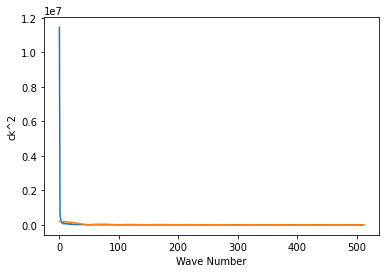

In [12]:
# Comp.Phys.HW5.Q1 : Exercise 7.6

from matplotlib.pylab import plot, show, xlim, ylim, xlabel, ylabel, hist
import numpy as np
from numpy.fft import rfft, irfft
import matplotlib.pyplot as plt
import urllib.request

# original data
url = 'http://www-personal.umich.edu/~mejn/cp/data/dow2.txt'
with urllib.request.urlopen(url) as response:
    html = response.read()
    
data=html.decode().split("\n")
dc_val=[]
for entry in data:
    vals = entry.split(" ")
    if (len(vals) == 1):
        if vals[0] == '':
            print(vals, "Not a value")
        else:
#             print(vals)
            dc_val.append(float(vals[0]))
                 
                 
print("Total number of entries = ", len(dc_val))

fig = plt.figure(figsize=(10,10))
axes = plt.axes()
axes.xaxis.set_major_locator(plt.MaxNLocator(10))
axes.yaxis.set_major_locator(plt.MaxNLocator(10))
plot(dc_val)
xlabel("Month from 2006")
ylabel("Daily Closing Values")
show()

# Discrete-Fourier 
print("Discrete-Fourier")
N = 1024
c = rfft(dc_val)
print(dc_val)
for k in range(50):
    print("Value of ", 1024/(k+1), " has coefficient =", abs(c[k])**2)

print("\n")
plot(abs(c))
xlabel("Wave Number")
ylabel("ck^2")

# Inverse-Fourier -- all but first 2%  = 0
print("Inverse-Fourier")

for i in range(N - 20):
    dc_val[-i] = 0
    
dc_val[0] = 9487.8
print(dc_val)

new_c2 = rfft(dc_val)
for k in range(50):
    print("Value of ", (1/N) * 1024/(k+1), " has coefficient =", abs(new_c2[k]))
    
plot(abs(new_c2))

# something must be wrong because I do not see large deviations at the start and end
